Import Libraries

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [ ]:
df = pd.read_csv("Facebook Metrics of Cosmetic Brand.csv")

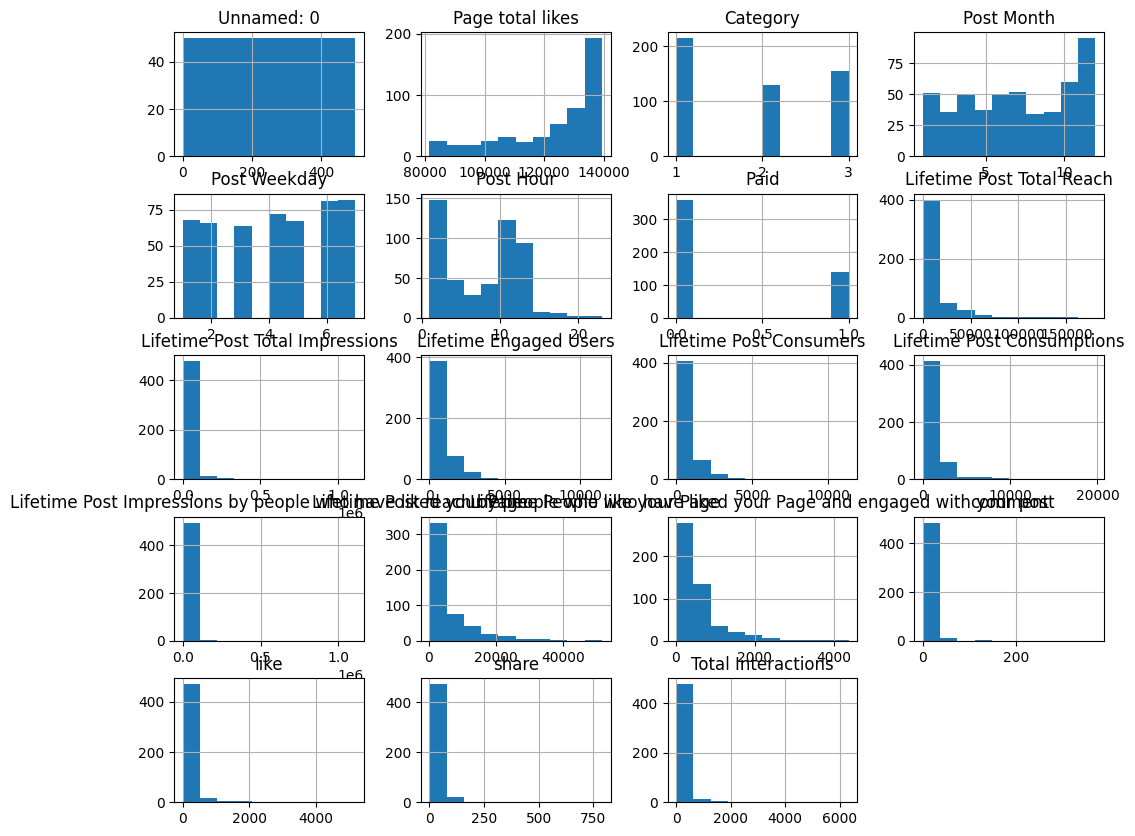

In [ ]:
df.hist(figsize=(12,10))
plt.show()

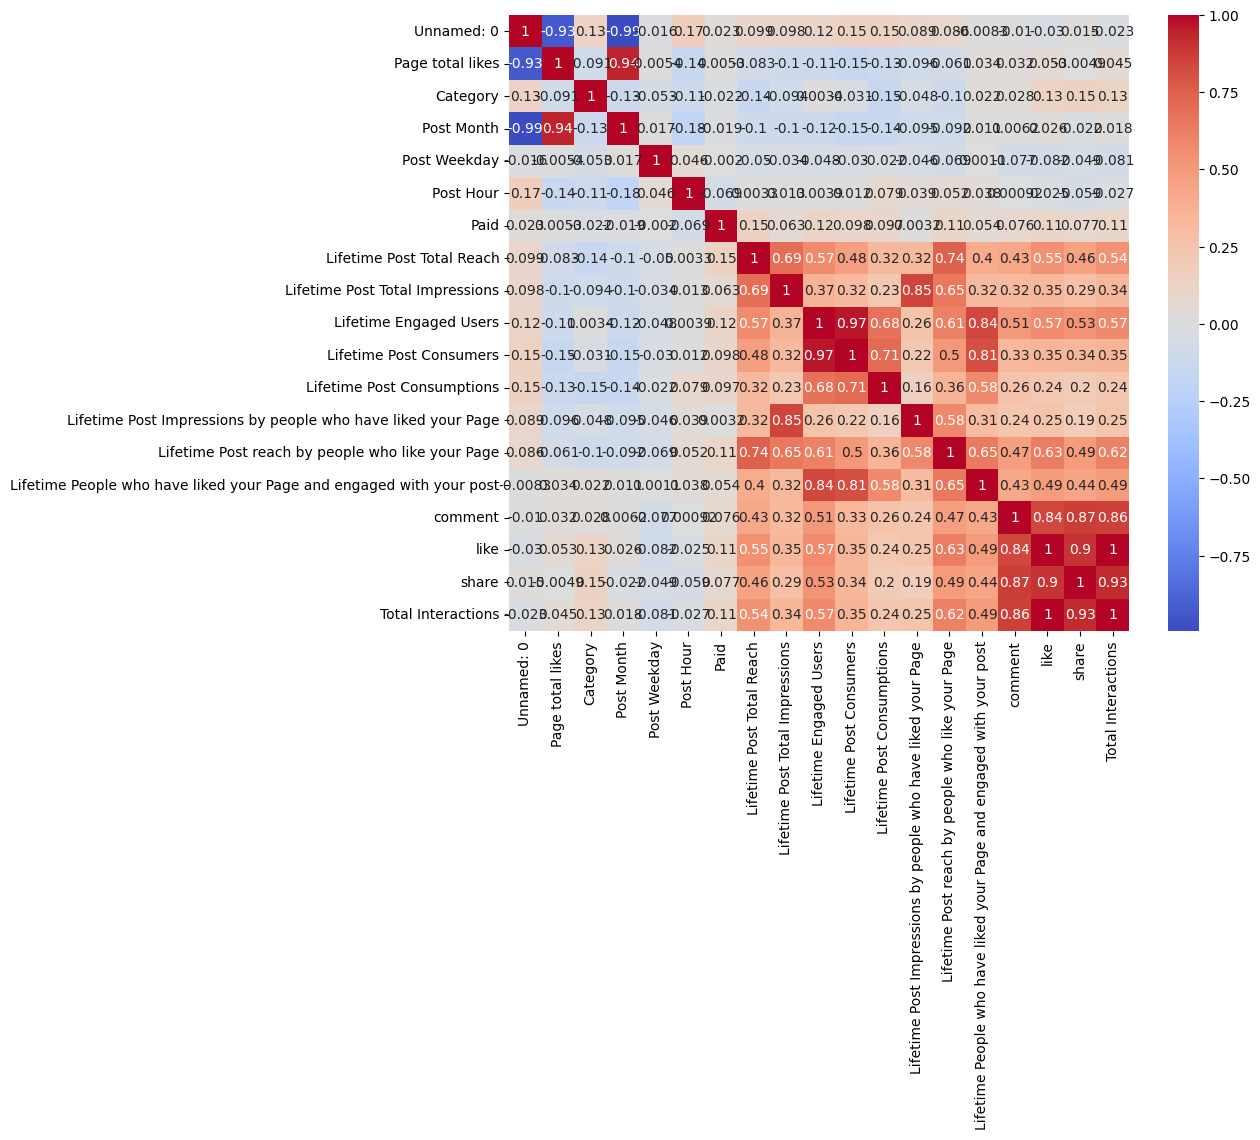

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="coolwarm")
plt.show()

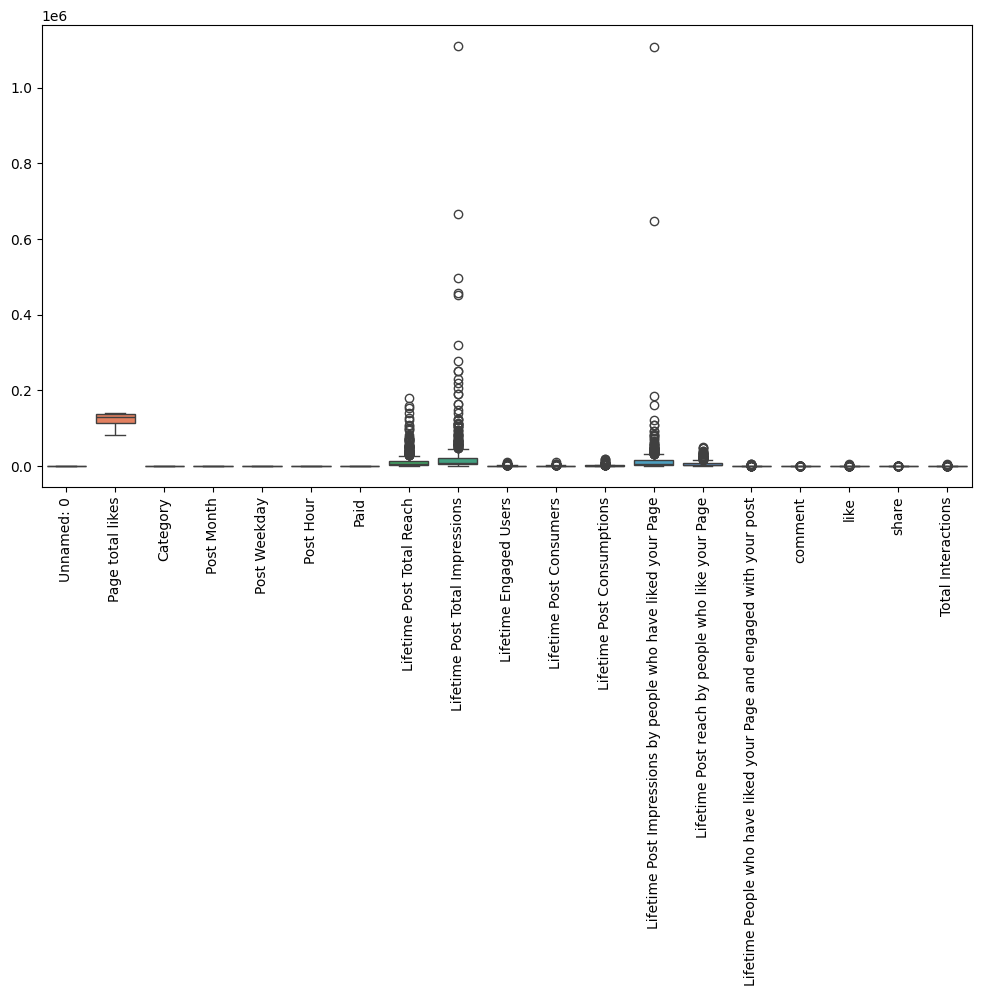

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

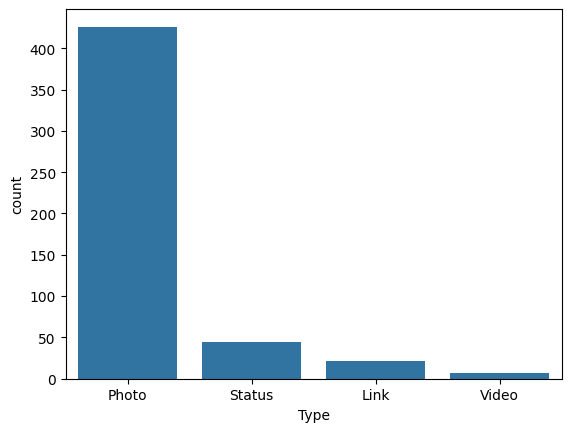

In [ ]:
sns.countplot(x='Type', data=df)
plt.show()

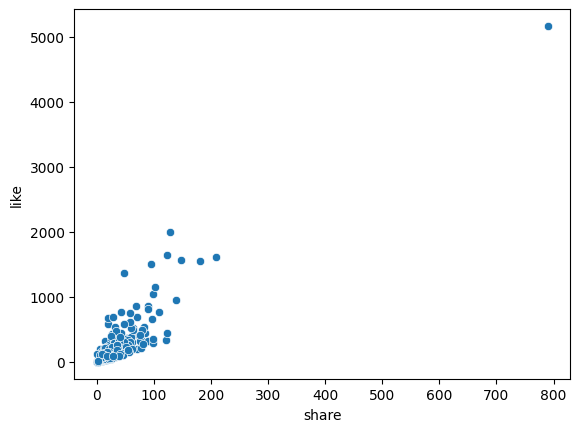

In [ ]:
sns.scatterplot(x='share', y='like', data=df)
plt.show()

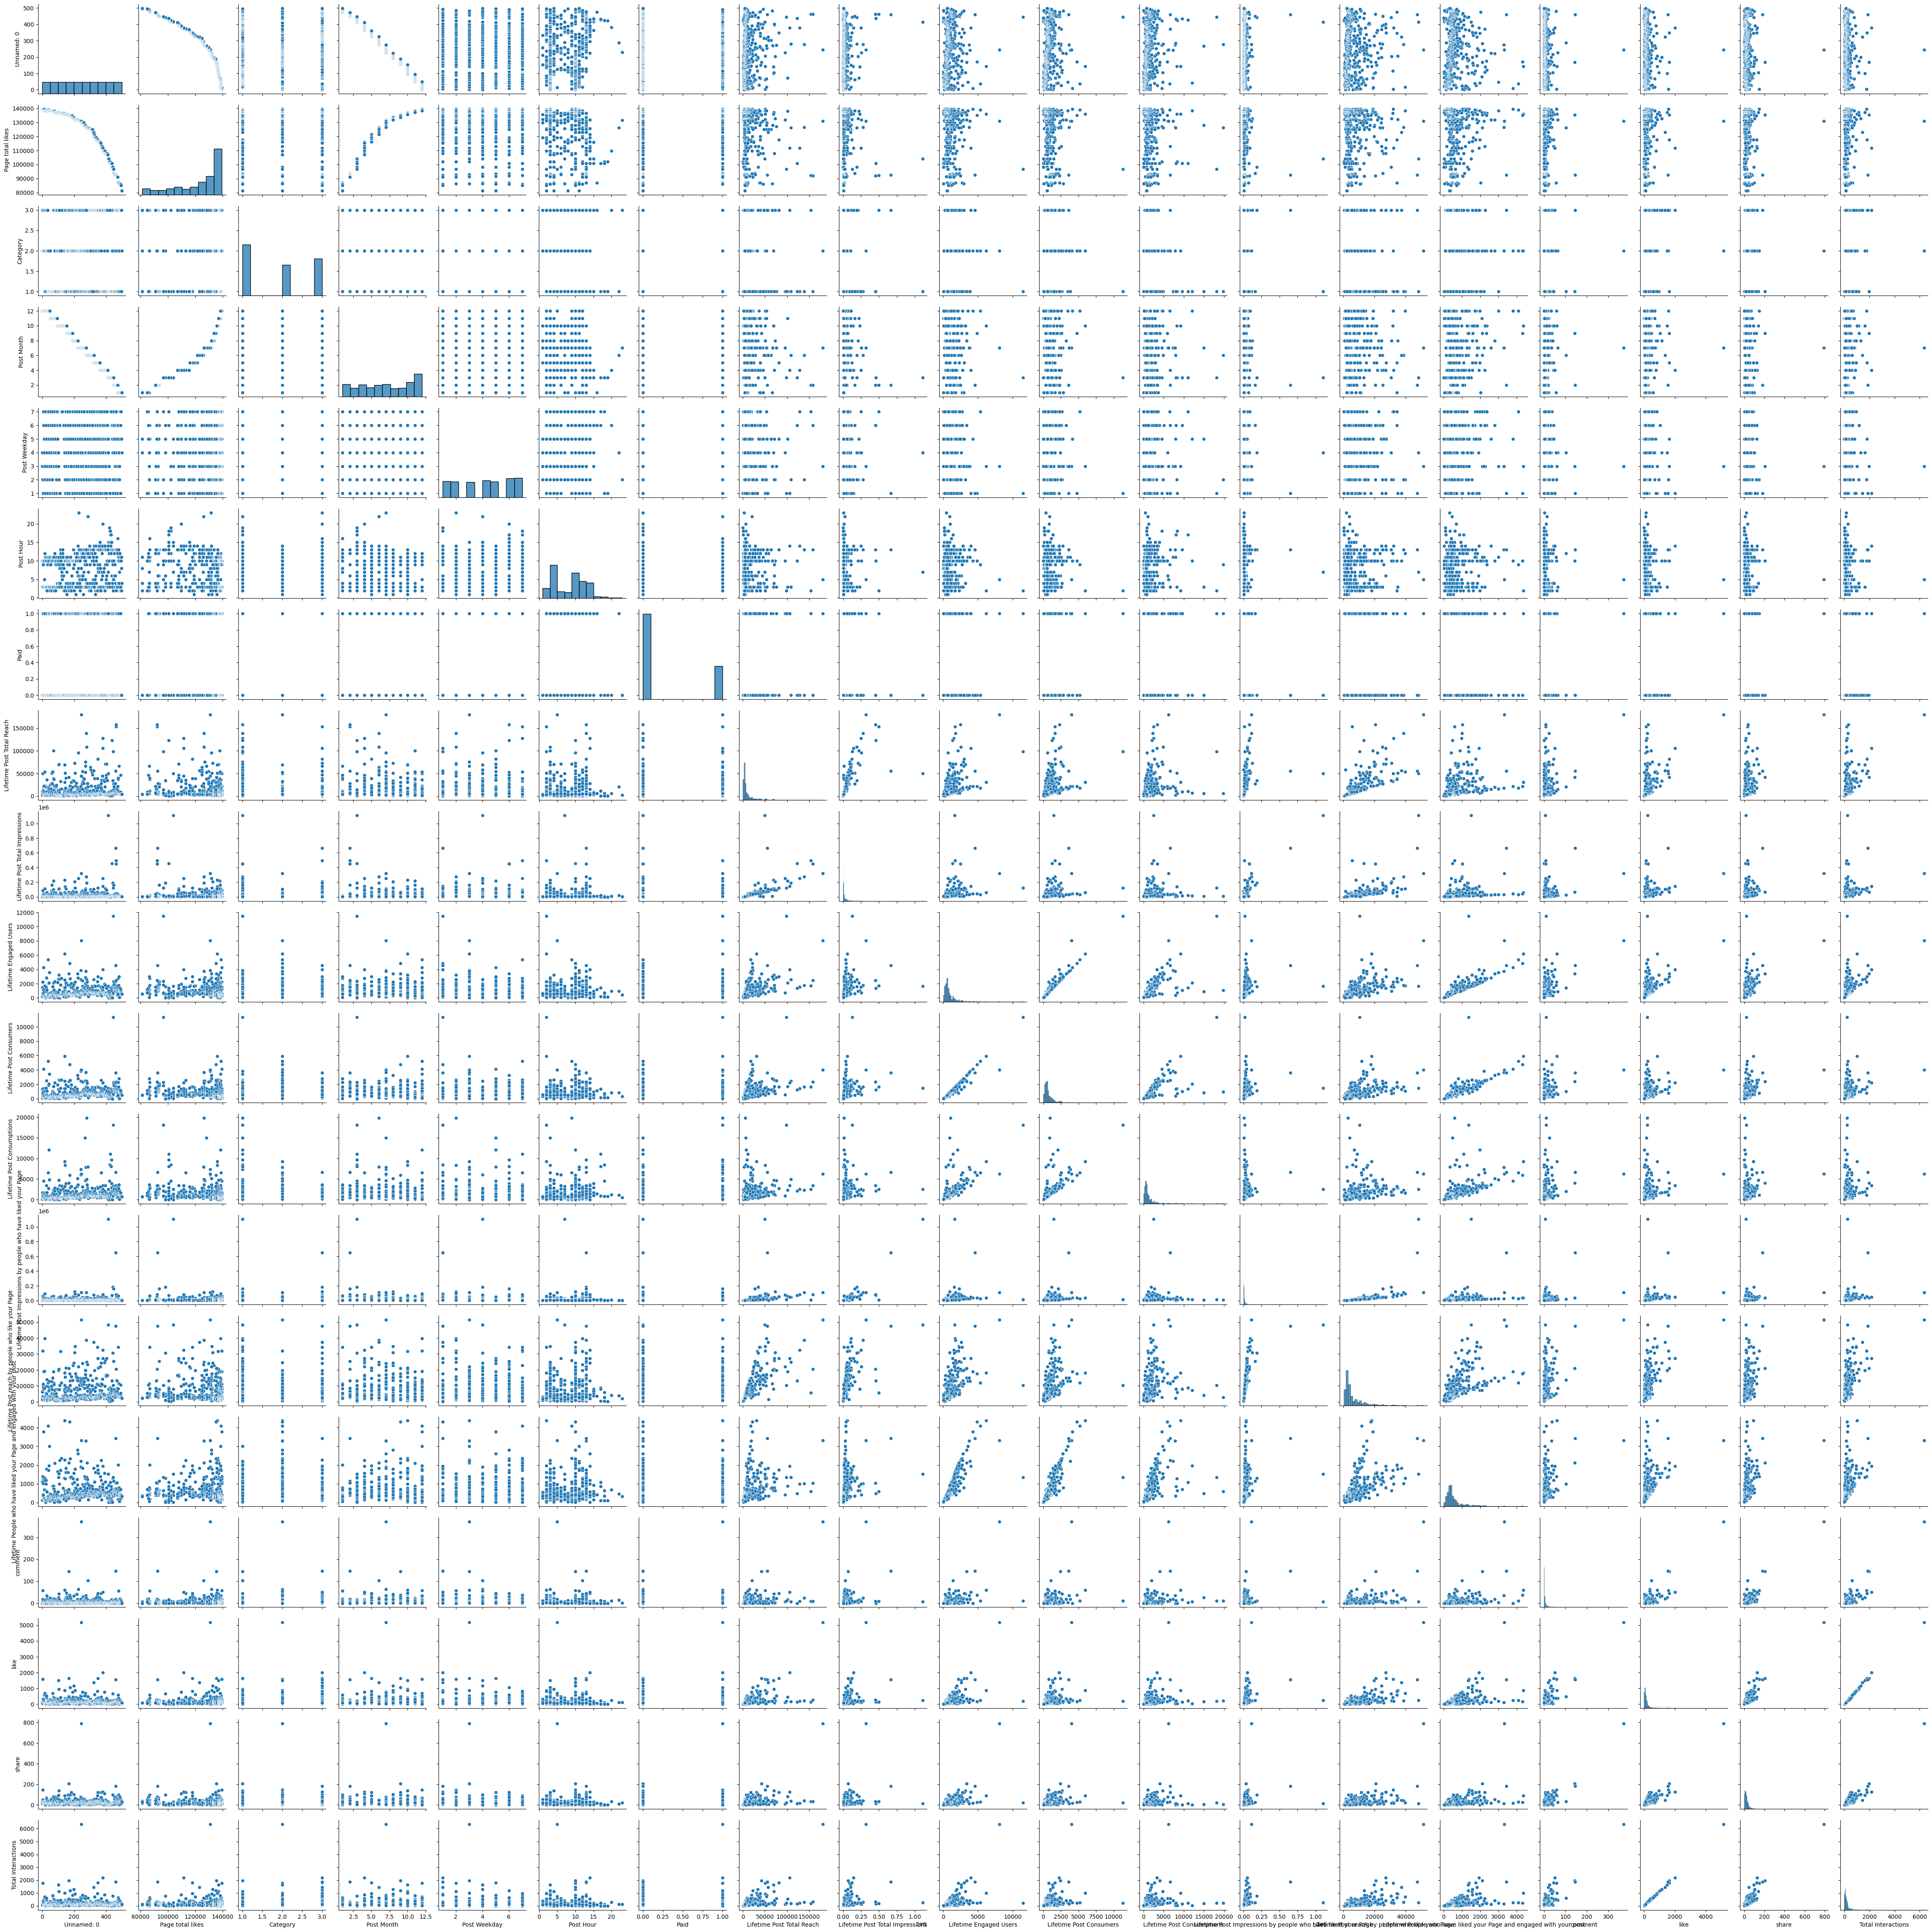

In [ ]:
sns.pairplot(df)
plt.show()

# **Arima**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['like'], order=(1,1,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)
print(forecast)

500    176.853420
501    177.860151
502    177.871956
503    177.872094
504    177.872096
505    177.872096
506    177.872096
507    177.872096
508    177.872096
509    177.872096
Name: predicted_mean, dtype: float64


# **Sarima**

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = df['like'] # Define ts using the 'like' column from the DataFrame

model = SARIMAX(ts,
                order=(1,1,1),        # (p,d,q)
                seasonal_order=(1,1,1,7))  # (P,D,Q,s)

result = model.fit()

print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                              like   No. Observations:                  500
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3554.059
Date:                           Wed, 01 Apr 2026   AIC                           7118.119
Time:                                   04:56:15   BIC                           7139.111
Sample:                                        0   HQIC                          7126.362
                                           - 500                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0135      0.078      0.173      0.862      -0.139       0.166
ma.L1         -1.0000      0.050    -19.958

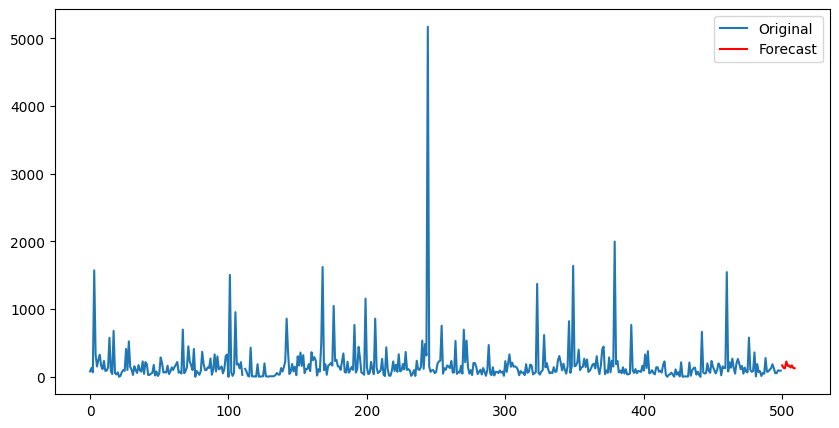

In [ ]:
forecast = result.forecast(steps=10)

plt.figure(figsize=(10,5))
plt.plot(ts, label='Original')
plt.plot(forecast, label='Forecast', color='red')
plt.legend()
plt.show()